# FX Pairs — Exploratory Data Analysis

**Docker image**: `ml4t`

## Purpose
Profile the OANDA 20-pair, 4-hour FX dataset that anchors the FX case study.
FX is OTC: there is no central tape, so quotes and reported volumes are
venue-specific. The notebook surveys coverage, quote conventions, OHLC
integrity, and the 4h→daily aggregation used by downstream chapters.

## Learning Objectives
- Load and inspect the 4-hour OHLC + indicative-volume panel for 20 pairs.
- Distinguish direct (USD-quoted), indirect (USD-base), and cross pairs.
- Read FX volume as an OANDA indicator, not an authoritative tape.
- Aggregate 4h bars to UTC-day daily bars and read the gap-pattern signal.

## Book reference
Chapter 2, §2.2 (asset-class market data — foreign exchange). The FX case
study built on this dataset lives in `case_studies/fx_pairs/`.

## Prerequisites
- OANDA 4h FX parquet files materialized under `ML4T_DATA_PATH`.
- Loader `data.load_fx_pairs`.

In [1]:
"""FX Pairs — Exploratory data analysis of OANDA currency pair data."""

import plotly.graph_objects as go
import polars as pl

from data import load_fx_pairs
from utils.data_quality import check_ohlc_invariants, per_asset_stats
from utils.style import COLORS

In [2]:
# Production defaults — Papermill injects overrides for CI
# (No tunable knobs: this notebook EDAs the full 20-pair universe via the
# canonical load_fx_pairs() API; there is no MAX_SYMBOLS / START_DATE knob to expose.)

## 1. Load and Inspect

In [3]:
fx_4h = load_fx_pairs(frequency="4h")

print("=== FX Dataset ===")
print(f"Shape: {fx_4h.shape}")
print(f"Columns: {fx_4h.columns}")
print(f"Date range: {fx_4h['timestamp'].min()} to {fx_4h['timestamp'].max()}")

=== FX Dataset ===
Shape: (478640, 7)
Columns: ['timestamp', 'symbol', 'open', 'high', 'low', 'close', 'volume']
Date range: 2011-01-02 14:00:00 to 2025-12-31 18:00:00


### Volume Disclaimer

**Important**: FX is an OTC market. Volume figures are indicative estimates from OANDA,
not authoritative exchange data. Do not interpret FX volume the same way as equity volume.

In [4]:
fx_4h.head()

timestamp,symbol,open,high,low,close,volume
datetime[ms],str,f64,f64,f64,f64,i64
2011-01-02 18:00:00,"""AUD_JPY""",83.0,83.332,82.8,82.875,986
2011-01-02 22:00:00,"""AUD_JPY""",82.877,83.015,82.698,82.796,4378
2011-01-03 02:00:00,"""AUD_JPY""",82.8,82.98,82.782,82.924,1934
2011-01-03 06:00:00,"""AUD_JPY""",82.926,83.03,82.826,83.03,3949
2011-01-03 10:00:00,"""AUD_JPY""",83.032,83.158,82.986,83.01,5296


In [5]:
# Available pairs
pairs = fx_4h["symbol"].unique().sort().to_list()
print(f"\nCurrency pairs ({len(pairs)}):")
for pair in pairs:
    print(f"  {pair}")


Currency pairs (20):
  AUD_JPY
  AUD_NZD
  AUD_USD
  CAD_JPY
  CHF_JPY
  EUR_AUD
  EUR_CAD
  EUR_CHF
  EUR_GBP
  EUR_JPY
  EUR_USD
  GBP_AUD
  GBP_CHF
  GBP_JPY
  GBP_USD
  NZD_JPY
  NZD_USD
  USD_CAD
  USD_CHF
  USD_JPY


### Symbol Normalization

The data uses underscore format (`EUR_USD`). The canonical format for this dataset is
concatenated (`EURUSD`). Here's how to convert:

In [6]:
# Normalize symbols: EUR_USD → EURUSD (canonical format)
# The raw file uses underscores; we normalize to concatenated format for downstream joins
fx = fx_4h.with_columns(pl.col("symbol").str.replace("_", "").alias("symbol"))

print("Symbol normalization example:")
print("  Raw format: EUR_USD, USD_JPY, GBP_USD")
print("  Canonical:  EURUSD, USDJPY, GBPUSD")
print(f"\nNormalized pairs: {fx['symbol'].unique().sort().to_list()[:6]} ...")

Symbol normalization example:
  Raw format: EUR_USD, USD_JPY, GBP_USD
  Canonical:  EURUSD, USDJPY, GBPUSD

Normalized pairs: ['AUDJPY', 'AUDNZD', 'AUDUSD', 'CADJPY', 'CHFJPY', 'EURAUD'] ...


## 2. Coverage Summary

In [7]:
# Per-pair statistics (using normalized symbols)
pairs = fx["symbol"].unique().sort().to_list()

pair_stats = per_asset_stats(
    fx,
    time_col="timestamp",
    asset_col="symbol",
    price_col="close",
    volume_col="volume",
)

pair_stats.sort("avg_volume", descending=True)

symbol,rows,start,end,avg_price,avg_volume
str,u32,datetime[ms],datetime[ms],f64,f64
"""GBPAUD""",23945,2011-01-02 14:00:00,2025-12-31 18:00:00,1.795271,27719.096262
"""GBPJPY""",23924,2011-01-02 18:00:00,2025-12-31 18:00:00,156.656959,22954.817673
"""EURCAD""",23921,2011-01-02 14:00:00,2025-12-31 18:00:00,1.44887,21140.860081
"""GBPCHF""",23924,2011-01-02 18:00:00,2025-12-31 18:00:00,1.302496,18534.499415
"""CHFJPY""",23919,2011-01-02 18:00:00,2025-12-31 18:00:00,122.492732,18296.437686
…,…,…,…,…,…
"""NZDUSD""",23943,2011-01-02 14:00:00,2025-12-31 18:00:00,0.702921,7312.247797
"""EURCHF""",23925,2011-01-02 14:00:00,2025-12-31 18:00:00,1.099216,6110.44698
"""EURGBP""",23922,2011-01-02 14:00:00,2025-12-31 18:00:00,0.846666,5989.497952


### Liquidity is venue-specific

Ranking pairs by average indicative volume shows something that looks wrong at
first: the global majors (EUR/USD, USD/JPY) are *not* at the top. That is
correct — this is OANDA's retail flow, not the interbank tape. The largest
interbank markets are simply not visible to a single retail venue. Read this as
a relative liquidity indicator on this venue, nothing more.

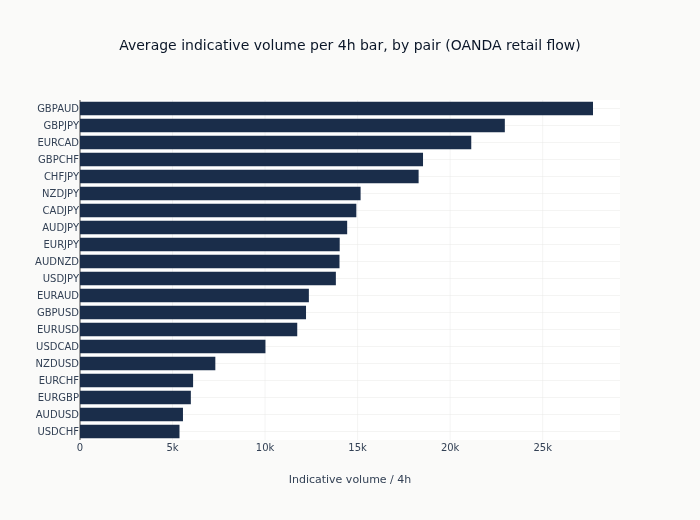

In [8]:
vol_rank = (
    fx.group_by("symbol")
    .agg(pl.col("volume").mean().alias("avg_volume"))
    .sort("avg_volume", descending=True)
)

fig = go.Figure(
    go.Bar(
        x=vol_rank["avg_volume"].to_list(),
        y=vol_rank["symbol"].to_list(),
        orientation="h",
        marker_color=COLORS["slate"],
    )
)
fig.update_layout(
    title="Average indicative volume per 4h bar, by pair (OANDA retail flow)",
    xaxis_title="Indicative volume / 4h",
    yaxis=dict(autorange="reversed"),
    height=520,
)
fig.show()

## 3. Quote Conventions

FX pairs follow **BASE/QUOTE** convention: the price is units of QUOTE per one
unit of BASE.

| Pair | Interpretation | USD Strength |
|------|----------------|--------------|
| EUR/USD = 1.10 | 1 EUR costs 1.10 USD | Down = USD stronger |
| USD/JPY = 150 | 1 USD costs 150 JPY | Up = USD stronger |
| EUR/GBP = 0.86 | 1 EUR costs 0.86 GBP | Cross rate (no USD) |

Rather than hand-label a subset, classify **all** pairs by rule: *Direct* if USD
is the quote (price = USD per base, so invert for a USD-strength composite),
*Indirect* if USD is the base (price already reads as USD strength), and *Cross*
if USD does not appear.

In [9]:
def classify_pair(sym: str) -> tuple[str, str]:
    """Classify a canonical FX symbol (e.g. 'EURUSD') by USD role."""
    base, quote = sym[:3], sym[3:]
    if quote == "USD":
        return "Direct", "invert for USD strength"
    if base == "USD":
        return "Indirect", "direct USD strength"
    return "Cross", "no USD"


quote_conventions = pl.DataFrame(
    [
        {
            "symbol": p,
            "convention": classify_pair(p)[0],
            "meaning": f"{p[3:]} per {p[:3]}",
            "usd_strength": classify_pair(p)[1],
        }
        for p in pairs
    ]
).sort("convention", "symbol")

print(f"Pairs classified: {quote_conventions.height} of {len(pairs)}")
print(quote_conventions["convention"].value_counts().sort("convention"))
quote_conventions

Pairs classified: 20 of 20
shape: (3, 2)
┌────────────┬───────┐
│ convention ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ Cross      ┆ 13    │
│ Direct     ┆ 4     │
│ Indirect   ┆ 3     │
└────────────┴───────┘


symbol,convention,meaning,usd_strength
str,str,str,str
"""AUDJPY""","""Cross""","""JPY per AUD""","""no USD"""
"""AUDNZD""","""Cross""","""NZD per AUD""","""no USD"""
"""CADJPY""","""Cross""","""JPY per CAD""","""no USD"""
"""CHFJPY""","""Cross""","""JPY per CHF""","""no USD"""
"""EURAUD""","""Cross""","""AUD per EUR""","""no USD"""
…,…,…,…
"""GBPUSD""","""Direct""","""USD per GBP""","""invert for USD strength"""
"""NZDUSD""","""Direct""","""USD per NZD""","""invert for USD strength"""
"""USDCAD""","""Indirect""","""CAD per USD""","""direct USD strength"""


## 4. Data Quality

In [10]:
# OHLC invariants
invariants = check_ohlc_invariants(fx)
invariants

check,valid_pct,applicable_rows,total_rows
str,f64,i64,i64
"""high_gte_low""",100.0,478640,478640
"""high_gte_open""",100.0,478640,478640
"""high_gte_close""",100.0,478640,478640
"""low_lte_open""",100.0,478640,478640
"""low_lte_close""",100.0,478640,478640
"""volume_non_negative""",100.0,478640,478640


In [11]:
# Check for weekend gaps (expected in FX, which trades 24/5)
eurusd = fx.filter(pl.col("symbol") == "EURUSD").sort("timestamp")

eurusd_gaps = eurusd.with_columns(
    pl.col("timestamp").diff().dt.total_hours().alias("hours_since_prev")
)

large_gaps = eurusd_gaps.filter(pl.col("hours_since_prev") > 24)
print(f"\nGaps > 24 hours (EURUSD): {len(large_gaps)} (should be weekends only)")


Gaps > 24 hours (EURUSD): 747 (should be weekends only)


The bar-to-bar gap distribution is the calendar made visible: a dominant spike
at the normal 4-hour cadence, and a second cluster around the weekend close
(Friday evening → Sunday evening). There is nothing in between — FX trades 24/5,
not 24/7, and the ~750 weekend gaps line up with ~15 years of weekends.

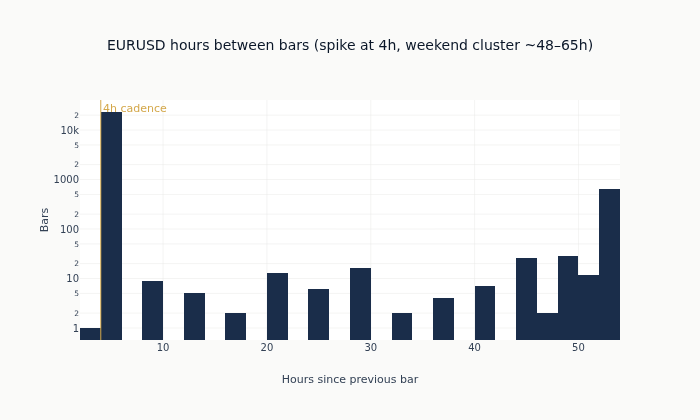

In [12]:
gap_hours = eurusd_gaps.drop_nulls("hours_since_prev")["hours_since_prev"].to_list()

fig = go.Figure()
fig.add_trace(
    go.Histogram(
        x=gap_hours,
        xbins=dict(start=0, end=72, size=2),
        marker_color=COLORS["slate"],
    )
)
fig.add_vline(x=4, line_color=COLORS["amber"], line_width=1)
fig.add_annotation(
    x=4,
    y=1,
    xref="x",
    yref="paper",
    text="4h cadence",
    showarrow=False,
    xanchor="left",
    yanchor="top",
    font=dict(color=COLORS["amber"]),
)
fig.update_layout(
    title="EURUSD hours between bars (spike at 4h, weekend cluster ~48–65h)",
    xaxis_title="Hours since previous bar",
    yaxis_title="Bars",
    yaxis_type="log",
    height=420,
)
fig.show()

## 5. Daily Aggregation

Aggregate 4-hour bars to daily for consistency with other datasets.

**Note**: This uses UTC midnight boundaries. FX daily bars are conventionally defined
by a session cutoff (often 5pm New York). For production, align to your broker's
convention. This simple calendar-day aggregation is sufficient for exploration.

In [13]:
# Daily aggregation (must be sorted for group_by_dynamic)
fx_daily = (
    fx.sort("symbol", "timestamp")
    .group_by_dynamic("timestamp", every="1d", group_by="symbol")
    .agg(
        [
            pl.col("open").first(),
            pl.col("high").max(),
            pl.col("low").min(),
            pl.col("close").last(),
            pl.col("volume").sum(),
        ]
    )
)

print(f"Daily aggregation (UTC boundaries) — shape: {fx_daily.shape}")
fx_daily.filter(pl.col("symbol") == "EURUSD").tail(5)

Daily aggregation (UTC boundaries) — shape: (94642, 7)


symbol,timestamp,open,high,low,close,volume
str,datetime[ms],f64,f64,f64,f64,i64
"""EURUSD""",2025-12-26 00:00:00,1.17873,1.17968,1.17616,1.1771,99014
"""EURUSD""",2025-12-28 00:00:00,1.1768,1.17864,1.17654,1.17842,10811
"""EURUSD""",2025-12-29 00:00:00,1.1784,1.17891,1.17494,1.17751,110397
"""EURUSD""",2025-12-30 00:00:00,1.1775,1.17798,1.17419,1.17426,83060
"""EURUSD""",2025-12-31 00:00:00,1.17424,1.17595,1.172,1.17459,92505


## Key Takeaways

Profile of the OANDA 4h FX panel that anchors the FX case study.

### Quantitative Findings
- **Panel scale**: 478,640 4h observations across 20 currency pairs spanning
  2011-01-02 → 2025-12-31. Each pair has ~23,920–23,950 4h bars.
- **Liquidity tiers (by indicative OANDA volume)**: GBPAUD, GBPJPY, EURCAD,
  GBPCHF and CHFJPY top the table at 18k–28k contracts/4h; the bottom of
  the universe (NZDUSD, EURCHF, EURGBP, AUDUSD, USDCHF) sits at 5k–7k.
  These rankings are *OANDA-specific* — interbank-market liquidity for
  EURUSD/USDJPY is the largest globally but is not visible to a single
  retail venue.
- **OHLC integrity**: 100% of 4h bars satisfy all six invariants
  (high ≥ low/open/close, low ≤ open/close, volume ≥ 0).
- **Session gaps**: 747 EURUSD inter-bar gaps exceed 24 h, matching the
  ~780 weekend closes over the ~15-year span — confirming the 24/5 calendar.
- **Daily roll-up**: UTC-boundary aggregation produces 94,642 daily rows
  across the panel (≈4,732 trading days × 20 pairs).

### Implications for Practitioners
- **Volume**: Treat as a relative liquidity indicator across pairs on this
  venue, not as an interbank tape.
- **Quote inversion**: USD strength composites must invert direct pairs
  (EUR/USD, GBP/USD, AUD/USD, NZD/USD); USD-base and cross pairs do not
  need inversion.
- **Daily session convention**: UTC-day aggregation is convenient for joins
  with the equity/crypto panels but is *not* a tradable session boundary;
  broker-specific 5pm-NY cutoffs are wired in `case_studies/fx_pairs/`
  downstream.

**Next**: `13_data_quality_framework` profiles the cross-asset DQ checks
that consume this panel and the others built up so far.